In [1]:
from FNO2D_def import *  # your 2D FNO definition file
import h5py
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
import numpy as np
import os
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

In [2]:
# Config

batch_size = 4  # reduce for 2D since fields are larger
lr = 2e-4
epochs = 500
val_patience = 25
sub = 1

modes1 = modes2 = 16
width = 128

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

# Paths
h5_path = path = "/scratch/mnhagen/datasets/heat2d_multires/heat2D_autoreg_N128_multi.h5"
dataset = "u"

In [3]:
# Dataset Definition

class NavierStokesDirectDataset(torch.utils.data.Dataset):
    """
    Dataset for learning the direct mapping ω₀ → ω_T from 2-frame trajectories.
    """

    def __init__(self, h5_path, split="train", split_ratio=(0.8, 0.2), sub = 1):
        super().__init__()
        with h5py.File(h5_path, "r") as f:
            self.omega = f[dataset][:]   # (num_samples, 2, N, N)
            self.X = f["X"][:]
            self.Y = f["Y"][:]

        self.sub = sub
        self.num_samples = self.omega.shape[0]
        n_train = int(self.num_samples * split_ratio[0])
        if split == "train":
            self.idxs = range(0, n_train)
        else:
            self.idxs = range(n_train, self.num_samples)

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, idx):
        i = self.idxs[idx]
        ω_in = self.omega[i, 0, ::self.sub, ::self.sub]    # initial
        ω_out = self.omega[i, 1, ::self.sub, ::self.sub]   # final

        # Add channel dimension (1, H, W)
        ω_in = torch.tensor(ω_in[None, :, :], dtype=torch.float32)
        ω_out = torch.tensor(ω_out[None, :, :], dtype=torch.float32)
        return ω_in, ω_out


In [ ]:
#Train model

train_ds = NavierStokesDirectDataset(h5_path, split="train", sub = sub)
val_ds = NavierStokesDirectDataset(h5_path, split="val", sub = sub)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

model = FNO2D(modes1, modes2, width)
model.q = torch.nn.Conv2d(width, 1, 1)  # one output channel (vorticity)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

best_val_loss = float("inf")
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for ω_in, ω_target in train_loader:
        ω_in, ω_target = ω_in.to(device), ω_target.to(device)
        optimizer.zero_grad()

        ω_pred = model(ω_in.permute(0, 2, 3, 1))  # (B, H, W, 1)
        ω_pred = ω_pred.permute(0, 3, 1, 2)       # back to (B, 1, H, W)

        loss = F.mse_loss(ω_pred, ω_target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for ω_in, ω_target in val_loader:
            ω_in, ω_target = ω_in.to(device), ω_target.to(device)
            ω_pred = model(ω_in.permute(0, 2, 3, 1))
            ω_pred = ω_pred.permute(0, 3, 1, 2)
            val_loss += F.mse_loss(ω_pred, ω_target).item()
    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    print(f"Epoch {epoch:03d} | Train: {train_loss:.4e} | Val: {val_loss:.4e}")

    # Early stopping
    if val_loss < best_val_loss * (1-1e-3):
        best_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= val_patience:
            print("Early stop triggered.")
            break

print("Training complete. Best val loss:", best_val_loss)


/scratch/mnhagen/myenv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 000 | Train: 2.3886e-03 | Val: 1.9632e-04
Epoch 001 | Train: 1.3202e-04 | Val: 6.9259e-05
Epoch 002 | Train: 3.8671e-05 | Val: 2.2381e-05
Epoch 003 | Train: 1.4740e-05 | Val: 1.0525e-05
Epoch 004 | Train: 8.1863e-06 | Val: 6.2990e-06
Epoch 005 | Train: 5.5485e-06 | Val: 4.8477e-06
Epoch 006 | Train: 4.2634e-06 | Val: 4.1062e-06
Epoch 007 | Train: 3.7376e-06 | Val: 3.1851e-06
Epoch 008 | Train: 3.1221e-06 | Val: 3.2446e-06
Epoch 009 | Train: 2.9653e-06 | Val: 2.3166e-06
Epoch 010 | Train: 2.7828e-06 | Val: 2.1970e-06
Epoch 011 | Train: 2.3478e-06 | Val: 1.8760e-06
Epoch 012 | Train: 2.6622e-06 | Val: 3.1258e-06
Epoch 013 | Train: 2.8562e-06 | Val: 5.3923e-06
Epoch 014 | Train: 3.0419e-06 | Val: 2.8874e-06
Epoch 015 | Train: 2.2107e-06 | Val: 1.5271e-06
Epoch 016 | Train: 1.8916e-06 | Val: 1.7784e-06
Epoch 017 | Train: 2.3227e-06 | Val: 2.9565e-06
Epoch 018 | Train: 3.0887e-06 | Val: 1.2902e-06
Epoch 019 | Train: 1.6101e-06 | Val: 1.4990e-06
Epoch 020 | Train: 2.1653e-06 | Val: 1.7

In [8]:
#Save model

model_name = "FNO2D_heat2d_multi128_2"

model_dir = "/scratch/mnhagen/models/heat2d"
os.makedirs(model_dir, exist_ok=True)
save_path = os.path.join(model_dir, model_name + ".pt")

torch.save(model.state_dict(), save_path)

The code below is for plotting model predictions; either skip the load model cell to use the model just trained or load a model to test

In [11]:
#Load model: heat2d

load_path = "/scratch/mnhagen/models/heat2d/FNO2D_heat2d_multi128.pt"
h5_path = path = "/scratch/mnhagen/datasets/heat2d_multires/heat2D_autoreg_N256_multi.h5"

model = FNO2D(modes1, modes2, width)
model.q = torch.nn.Conv2d(width, 1, 1)  # one output channel (vorticity)
model.load_state_dict(torch.load(load_path, map_location=device))
model.to(device)
model.eval()

FNO2D(
  (p): Linear(in_features=3, out_features=128, bias=True)
  (conv0): SpectralConv2d()
  (conv1): SpectralConv2d()
  (conv2): SpectralConv2d()
  (conv3): SpectralConv2d()
  (mlp0): MLP(
    (mlp1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
    (mlp2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (mlp1): MLP(
    (mlp1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
    (mlp2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (mlp2): MLP(
    (mlp1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
    (mlp2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (mlp3): MLP(
    (mlp1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
    (mlp2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (w0): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  (w1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  (w2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  (w3): Conv2d(128, 128, kernel_size=(1, 1), stride=(1,

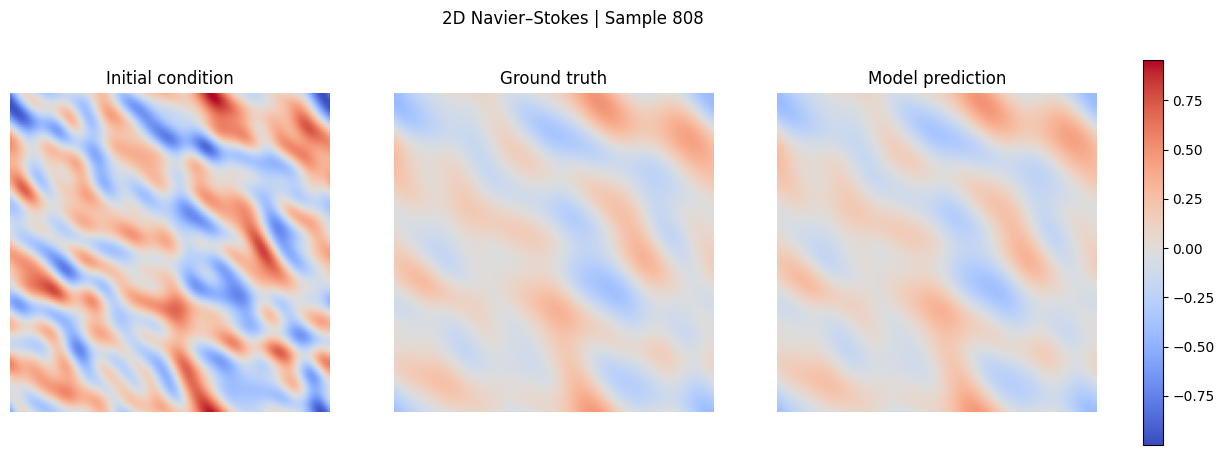

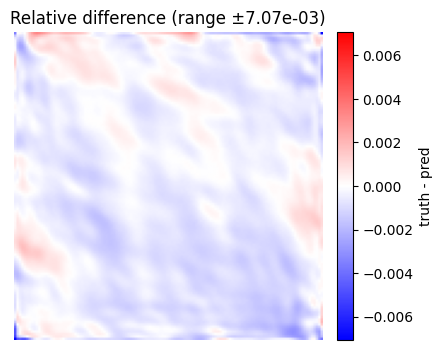

In [6]:
# Plot model prediction

sample_idx = 808

with h5py.File(h5_path, "r") as f:
    omega = f[dataset][:]  # (num_samples, 2, N, N)
omega0 = omega[sample_idx, 0, ::sub, ::sub]
omegaT = omega[sample_idx, 1, ::sub, ::sub]


ω_in = torch.tensor(omega0[None, None, :, :], dtype=torch.float32).to(device)  # (1,1,H,W)
with torch.no_grad():
    ω_pred = model(ω_in.permute(0, 2, 3, 1))  # -> (1,H,W,1)
ω_pred = ω_pred[0, ..., 0].cpu().numpy()  # (H,W)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Initial condition", "Ground truth", "Model prediction"]
fields = [omega0, omegaT, ω_pred]

vmin = min(np.min(f) for f in fields)
vmax = max(np.max(f) for f in fields)

for ax, field, title in zip(axes, fields, titles):
    im = ax.imshow(field, cmap="coolwarm", origin="lower", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.025, pad=0.04)
plt.suptitle(f"2D Navier–Stokes | Sample {sample_idx}")
#plt.tight_layout()
plt.show()


diff = omegaT - ω_pred
max_abs_diff = np.max(np.abs(diff))

plt.figure(figsize=(5, 4))
plt.imshow(diff, cmap="bwr", origin="lower",
           vmin=-max_abs_diff, vmax=max_abs_diff)
plt.colorbar(fraction=0.046, pad=0.04, label="truth - pred")
plt.title(f"Relative difference (range ±{max_abs_diff:.2e})")
plt.axis("off")
plt.show()